# **Unsupervised Learning**

Unsupervised learning, unlike supervised learning, deals with unlabeled data. Since there are no predefined labels or outcomes to compare against, evaluating the performance of unsupervised learning models can be challenging. Here are some common evaluation metrics used for different
unsupervised learning tasks:

### **Clustering**

Clustering aims to group similar data points together. Key evaluation metrics include:

1. **Silhouette Score**:
   - Measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation).
   - Ranges from -1 to 1, where higher values indicate better-defined clusters.

2. **Davies-Bouldin Index**:
   - Ratio of the sum of within-cluster scatter to between-cluster separation.
   - Lower values indicate better clustering.

3. **Calinski-Harabasz Index (Variance Ratio Criterion)**:
   - Ratio of the sum of between-cluster dispersion and within-cluster dispersion.
   - Higher values indicate better clustering.




## **Mall Customer Segmentation Dataset**

### **Target:**
The target of this project is to apply K-means clustering to group customers into distinct segments based on their age, gender, annual income, and spending score. By doing so, one aim to:
- Identify clusters of customers with similar purchasing behaviors.
- Determine which customer segments are most receptive to marketing strategies.
- Optimize marketing efforts to improve customer engagement and satisfaction.
  


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#file_path = '/content/drive/My Drive/Mall Dataset/Mall_Customers.csv'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')




In [2]:
# Load your data
data = pd.read_csv('/content/Mall Customers.csv')

In [3]:
# Inspect the data
data.head()




,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Identify categorical and numerical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numerical_cols = data.select_dtypes(include=['float', 'int']).columns.tolist()



In [6]:
# One-hot encode the categorical columns
ohe = OneHotEncoder()
encoded_categorical_data = ohe.fit_transform(data[categorical_cols]).toarray()
encoded_categorical_df = pd.DataFrame(encoded_categorical_data, columns=ohe.get_feature_names_out(categorical_cols))
print(encoded_categorical_df)





     Gender_Female  Gender_Male
0              0.0          1.0
1              0.0          1.0
2              1.0          0.0
3              1.0          0.0
4              1.0          0.0
..             ...          ...
195            1.0          0.0
196            1.0          0.0
197            0.0          1.0
198            0.0          1.0
199            0.0          1.0

[200 rows x 2 columns]


In [7]:
# Standard scale the numerical columns
scaler = StandardScaler()
scaled_numerical_data = scaler.fit_transform(data[numerical_cols])
scaled_numerical_df = pd.DataFrame(scaled_numerical_data, columns=numerical_cols)



In [8]:
# Combine the processed numerical and categorical data
processed_data = pd.concat([scaled_numerical_df, encoded_categorical_df], axis=1)



In [9]:
processed_data.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,-1.723412,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.706091,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.688771,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.671450,-1.137502,-1.700830,1.040418,1.0,0.0
4,-1.654129,-0.563369,-1.662660,-0.395980,1.0,0.0


In [10]:
# Apply the KMeans algorithm and evaluate using the elbow method and silhouette score
inertia = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

K = range(2, 11)  # Starting from 2 because silhouette score is not defined for k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(processed_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(processed_data, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(processed_data, kmeans.labels_))
    calinski_harabasz_scores.append(calinski_harabasz_score(processed_data, kmeans.labels_))



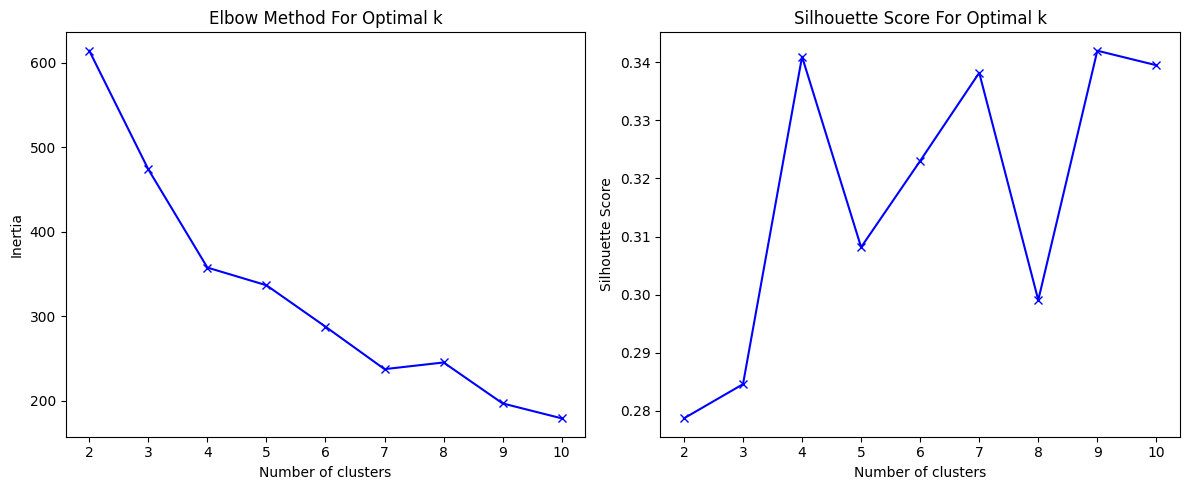

In [11]:
# Plot the elbow method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')

# Plot the silhouette scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Optimal k')

plt.tight_layout()
plt.show()



In [12]:
# Determine the best number of clusters using the silhouette score
optimal_k = K[np.argmax(silhouette_scores)]
print(f"The optimal number of clusters based on silhouette score is: {optimal_k}")




The optimal number of clusters based on silhouette score is: 9


In [13]:
# Fit the final KMeans model with the optimal number of clusters
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_optimal.fit(processed_data)

# Add the cluster labels to the original data
data['Cluster'] = kmeans_optimal.labels_

# Evaluate the final clustering
final_inertia = kmeans_optimal.inertia_
final_silhouette_score = silhouette_score(processed_data, kmeans_optimal.labels_)
final_davies_bouldin_score = davies_bouldin_score(processed_data, kmeans_optimal.labels_)
final_calinski_harabasz_score = calinski_harabasz_score(processed_data, kmeans_optimal.labels_)

print(f"Final Inertia: {final_inertia}")
print(f"Final Silhouette Score: {final_silhouette_score}")
print(f"Final Davies-Bouldin Index: {final_davies_bouldin_score}")
print(f"Final Calinski-Harabasz Index: {final_calinski_harabasz_score}")

Final Inertia: 196.8689983473076
Final Silhouette Score: 0.34199345177333496
Final Davies-Bouldin Index: 0.9910226583015418
Final Calinski-Harabasz Index: 85.09655052393444


In [14]:
# Use PCA for dimensionality reduction

# Apply PCA and keep the top 2 principal components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(processed_data)

# Apply KMeans on the reduced data
inertia_pca = []
silhouette_scores_pca = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    inertia_pca.append(kmeans.inertia_)
    silhouette_scores_pca.append(silhouette_score(pca_data, kmeans.labels_))
    silhouette_scores.append(silhouette_score(processed_data, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(processed_data, kmeans.labels_))
    calinski_harabasz_scores.append(calinski_harabasz_score(processed_data, kmeans.labels_))


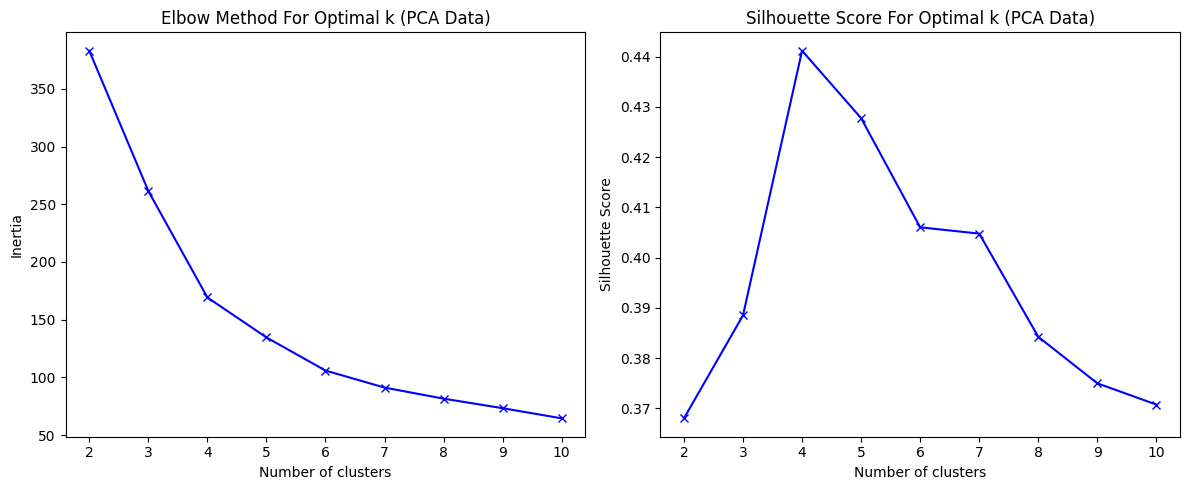

In [15]:
# Plot the elbow method for PCA data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, inertia_pca, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k (PCA Data)')

# Plot the silhouette scores for PCA data
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores_pca, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Optimal k (PCA Data)')

plt.tight_layout()
plt.show()



In [16]:
# Determine the best number of clusters using the silhouette score for PCA data
optimal_k_pca = K[np.argmax(silhouette_scores_pca)]
print(f"The optimal number of clusters based on silhouette score for PCA data is: {optimal_k_pca}")




The optimal number of clusters based on silhouette score for PCA data is: 4


In [17]:
# Fit the final KMeans model with the optimal number of clusters on PCA data
kmeans_optimal_pca = KMeans(n_clusters=optimal_k_pca, random_state=42)
kmeans_optimal_pca.fit(pca_data)

# Add the cluster labels to the original data
data['Cluster_PCA'] = kmeans_optimal_pca.labels_

# Evaluate the final clustering for PCA data
final_inertia_pca = kmeans_optimal_pca.inertia_
final_silhouette_score_pca = silhouette_score(pca_data, kmeans_optimal_pca.labels_)
final_davies_bouldin_score_pca = davies_bouldin_score(pca_data, kmeans_optimal_pca.labels_)
final_calinski_harabasz_score_pca = calinski_harabasz_score(pca_data, kmeans_optimal_pca.labels_)

print(f"Final Inertia (PCA): {final_inertia_pca}")
print(f"Final Silhouette Score (PCA): {final_silhouette_score_pca}")
print(f"Final Davies-Bouldin Index (PCA): {final_davies_bouldin_score_pca}")
print(f"Final Calinski-Harabasz Index (PCA): {final_calinski_harabasz_score_pca}")

Final Inertia (PCA): 169.2235467055904
Final Silhouette Score (PCA): 0.4411725854112817
Final Davies-Bouldin Index (PCA): 0.7574360995703253
Final Calinski-Harabasz Index (PCA): 190.35345533875565
